In [4]:
import os, sys
import torch
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("")), 'src'))

from noise_scheduling import CFG, DiffusionScheduler
# from preprocessing import load_channels, visualize_image

..\tests  , dummy data
Source shape: torch.Size([3, 512, 512])
Target shape: torch.Size([3, 512, 512])


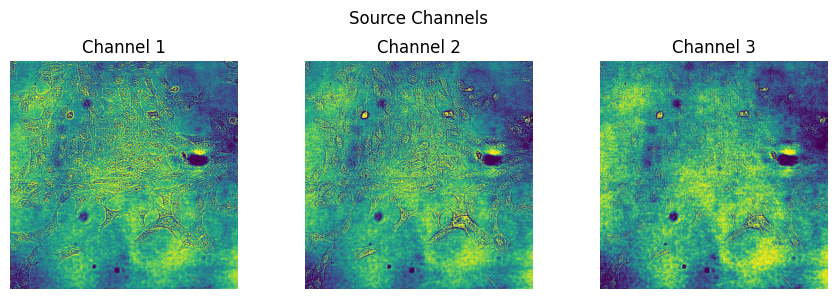

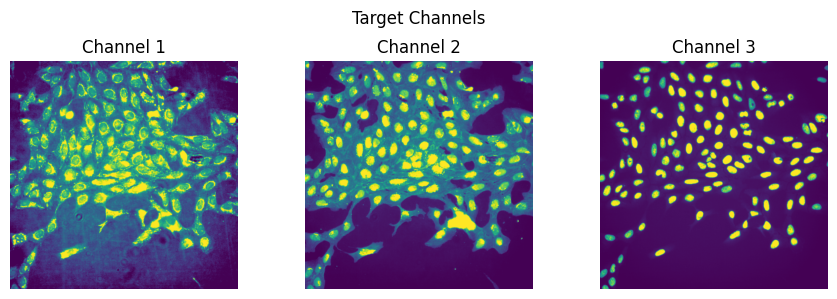

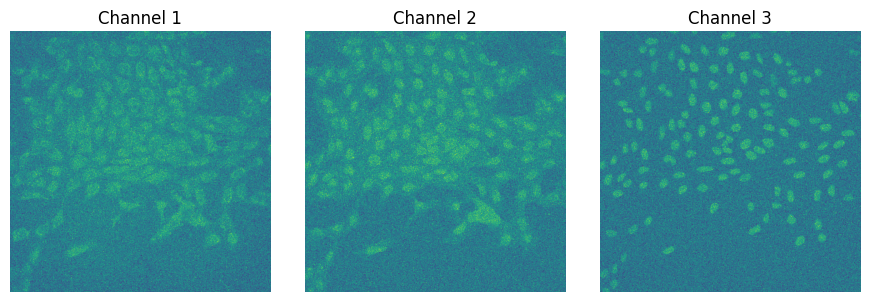

In [10]:

from data_loader import DiffusionDataset, get_diffusion_dataloader, visualize_image_channels

# 1) Point to the CSV that lists your partial paths for the dummy data:
csv_list = [os.path.join('..', "tests", "sdfsd_dummy data.csv")]

# 2) Create the dataset (channels 1–3 as “source”, 4–6 as “target”):
dataset = DiffusionDataset(
    csv_file_list=csv_list,
    images_dir=os.path.join('..', "tests",),
    source_channels=[6, 7, 8],
    target_channels=[1, 2, 5],
    img_size=(512,512)
)

# 3) Pull out one sample:
src_tensor, tgt_tensor = dataset[0]
print("Source shape:", src_tensor.shape)   # e.g. (3, 512, 512)
print("Target shape:", tgt_tensor.shape)   # e.g. (3, 512, 512)

# 4) Visualize if you like:
visualize_image_channels(src_tensor, title="Source Channels")
visualize_image_channels(tgt_tensor, title="Target Channels")

config = CFG(kappa=2.0, p=0.5, eta_T=0.999, T=50)
scheduler = DiffusionScheduler(config)
result = scheduler.get_noisy_image(20, src_tensor, tgt_tensor)
visualize_image_channels(result)

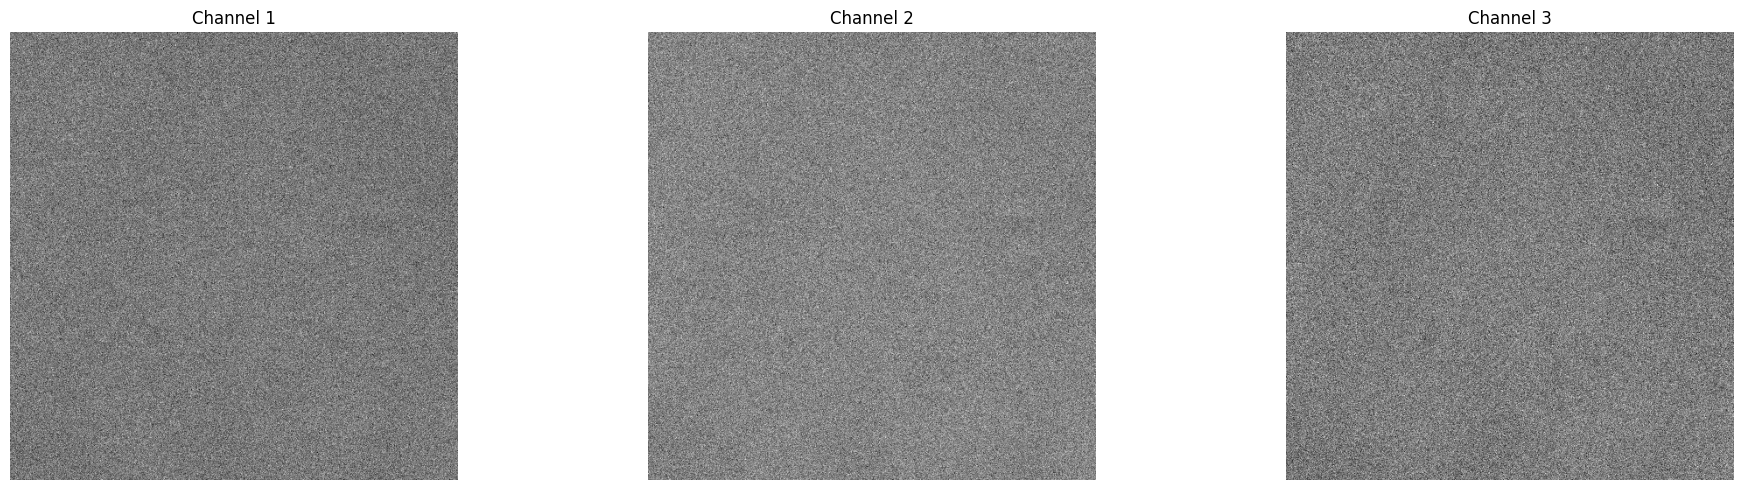

In [ ]:
config = CFG(kappa=2.0, p=0.5, eta_T=0.999, T=50)
scheduler = DiffusionScheduler(config)
result = scheduler.get_noisy_image(30, images[:, :, 3:], images[:, :, :3],)
visualize_image(result)
